### Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Single Particle in 2D domain

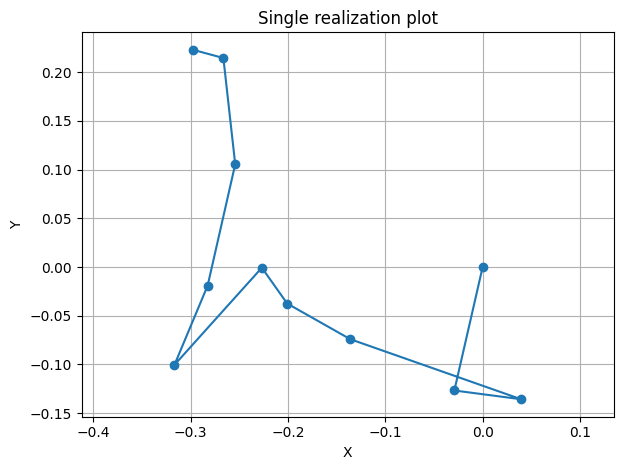

In [2]:
#for a single particle 

#number of steps
n_steps = 10
dt = 0.01 #for both x and y
espilon = np.sqrt(dt)

time = np.linspace(0, n_steps*dt, n_steps+1)

sigma  = np.eye(2)
b = 0

# intial value
X_0 = np.zeros((1,2))

# solution array with inital value
X = np.zeros((n_steps+1, 2))
X[0,:] = X_0

#time step
for i in range(n_steps):
    xi = np.random.normal(0,1,size=2)
    X[i+1,:] = X[i,:] +  b* dt + espilon*sigma@xi

# plot one relization
plt.plot(X[:,0], X[:,1], '-o', )
plt.title("Single realization plot")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.tight_layout()
plt.axis("equal")
plt.show()

    

### Single Particle in 2D with both reflection and rejection BCs

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


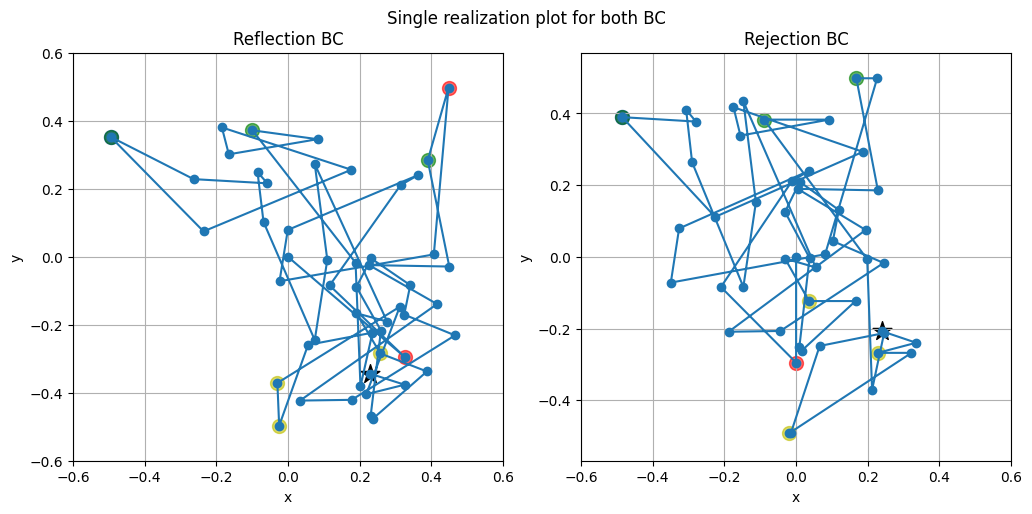

Final x value for reflection is [ 0.22988814 -0.3441376 ] and rejection is [ 0.23963662 -0.20753028]


In [3]:
#repeat but for rejection boundry, and compare the two results

#number of steps
n_steps = 50
dt = 0.05
espilon = np.sqrt(dt)

time = np.linspace(0, dt*n_steps, n_steps+1)
# time = np.zeros(n_steps+1)

#set the boundries
bc_x1 = -0.5
bc_x2 = 0.5
bc_y1 = -0.5
bc_y2 = 0.5

#drift and diffusion coefficents
sigma  = np.eye(2)
b = np.array([0,0])

# intial value
# X_0 = np.array( [np.random.uniform(bc_x1,bc_x2), np.random.uniform(bc_y1,bc_y2)] )
X_0 = np.array([0,0])

# solution array with inital value
X_ref = np.zeros((n_steps+1, 2))
X_rej = np.zeros((n_steps+1, 2))

X_ref[0] = np.copy(X_0)
X_rej[0] = np.copy(X_0)

#keep track of the reflections and rejections
reflections = []
rejections = []


#precompute xi values
xi = np.random.normal(0,1,size=(n_steps, 2))


#time step
for i in range(n_steps):
    X_ref[i+1,:] = X_ref[i,:] +  b* dt + espilon*sigma@xi[i,:]
    
    if X_ref[i+1,0] < bc_x1:
        X_ref[i+1,0] = 2*bc_x1 - X_ref[i+1,0]
        reflections.append((X_ref[i+1,:], "b")) #remember the location of the reflection
    
    if X_ref[i+1,0] > bc_x2:
        X_ref[i+1,0] = 2*bc_x2 - X_ref[i+1,0]
        reflections.append((X_ref[i+1,:], "r"))

    if X_ref[i+1,1] < bc_y1:
        X_ref[i+1,1] = 2*bc_y1 - X_ref[i+1,1]
        reflections.append((X_ref[i+1,:], "y")) #remember the location of the reflection
    
    if X_ref[i+1,1] > bc_y2:
        X_ref[i+1,1] = 2*bc_y2 - X_ref[i+1,1]
        reflections.append((X_ref[i+1,:], "g"))

    
    #do the same but for rejection
    X_rej[i+1,:] = X_rej[i,:] +  b* dt + espilon*sigma@xi[i,:]
    
    if X_rej[i+1,0] < bc_x1:
        X_rej[i+1,0] = X_rej[i,0]
        rejections.append((X_rej[i+1,:], "b")) #remember the location of the reflection
    
    if X_rej[i+1,0] > bc_x2:
        X_rej[i+1,0] = X_rej[i,0]
        rejections.append((X_rej[i+1,:], "r"))

    if X_rej[i+1,1] < bc_y1:
        X_rej[i+1,1] = X_rej[i,1]
        rejections.append((X_rej[i+1,:], "y")) 
    
    if X_rej[i+1,1] > bc_y2:
        X_rej[i+1,1] = X_rej[i,1]
        rejections.append((X_rej[i+1,:], "g"))



# plot one relization
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

fig.suptitle("Single realization plot for both BC")
plt.axis("equal")
plt.tight_layout()

ax[0].scatter(X_ref[-1,0], X_ref[-1,1], marker='*', s=200, c='black')
ax[0].plot(X_ref[:,0], X_ref[:,1], '-o')


for x , c in reflections:
    ax[0].scatter(x[0], x[1], s=100, c=c, alpha=.6)

ax[0].set_title("Reflection BC")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
ax[0].set_xlim(bc_x1-0.1, bc_x2+0.1)
ax[0].set_ylim(bc_y1-0.1, bc_y2+0.1)
ax[0].grid(True)


ax[1].scatter(X_rej[-1,0], X_rej[-1,1], marker='*', s=200, c='black')
ax[1].plot(X_rej[:,0], X_rej[:,1], '-o')
for x, c in rejections:
    ax[1].scatter(x[0], x[1], s=100, c=c, alpha=.6)

ax[1].set_title("Rejection BC")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")
ax[1].set_xlim(bc_x1-0.1, bc_x2+0.1)
ax[1].set_ylim(bc_y1-0.1, bc_y2+0.1)
ax[1].grid(True)



plt.show()

print(f"Final x value for reflection is {X_ref[-1,:]} and rejection is {X_rej[-1,:]}")
    


### Multiple particles in 2d domain

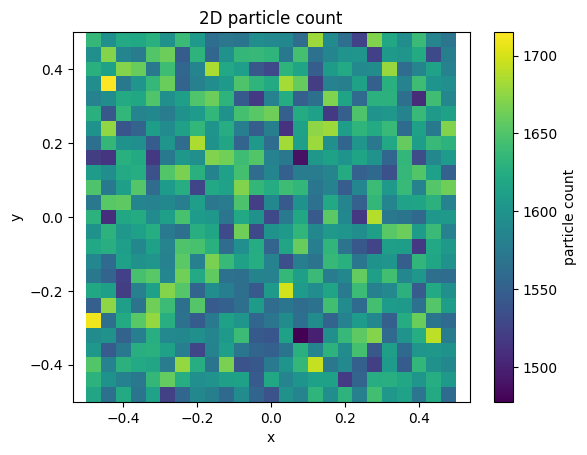

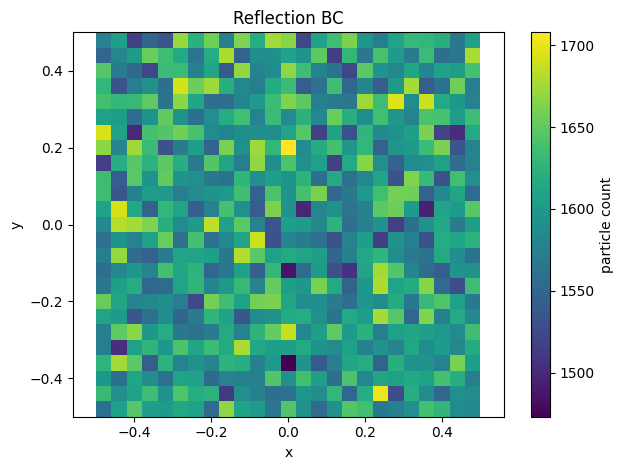

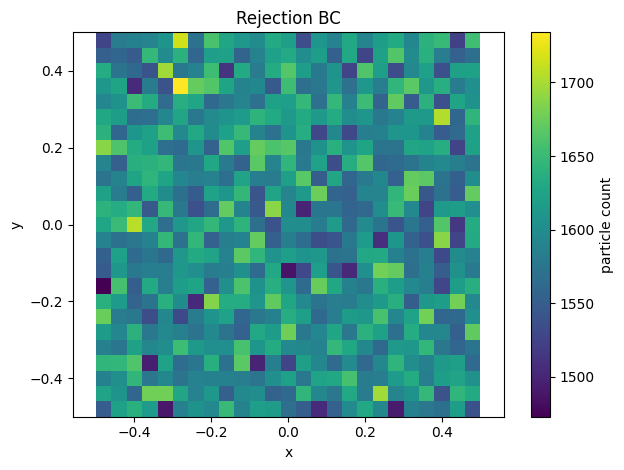

In [4]:

#number of particales
n_parts = 1000000

#number of steps
n_steps = 5
dt = 0.01
espilon = np.sqrt(dt)


#set the boundries
bc_x1 = -0.5
bc_x2 = 0.5
bc_y1 = -0.5
bc_y2 = 0.5

#drift and diffusion coefficents
sigma  = np.eye(2)
b = np.array([0,0])

# intial values
X_0 = np.column_stack([np.random.uniform(bc_x1,bc_x2, n_parts), np.random.uniform(bc_y1,bc_y2, n_parts)] )

# solution array with inital value
X_ref = np.zeros((n_steps+1, n_parts, 2))
X_rej = np.zeros((n_steps+1, n_parts, 2))

X_ref[0,:,:] = np.copy(X_0)
X_rej[0,:,:] = np.copy(X_0)

# plt.hist(X_0, bins=20, density=True)
# plt.title("Initialization histogram")
# plt.xlim((bc_1, bc_2))
# plt.show()


plt.hist2d(X_0[:, 0],X_0[:, 1],bins=25, range=[[bc_x1, bc_x2], [bc_y1, bc_y2]])

plt.colorbar(label="particle count")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D particle count")
plt.axis("equal")
plt.show()


#precompute xi values
xi = np.random.normal(0,1,size=(n_steps, n_parts, 2))

#time step
for i in range(n_steps):
    X_ref[i+1,:,:] = X_ref[i,:,:] +  b* dt + espilon* xi[i,:,:]@sigma
    
    #update the new value based on reflection rules
    selection = X_ref[i+1,:,0] < bc_x1
    X_ref[i+1, selection, 0] = 2*bc_x1 - X_ref[i+1, selection, 0]

    selection = X_ref[i+1,:,0] > bc_x2
    X_ref[i+1, selection, 0] = 2*bc_x2 - X_ref[i+1, selection, 0]

    selection = X_ref[i+1,:,1] < bc_y1
    X_ref[i+1, selection, 1] = 2*bc_y1 - X_ref[i+1, selection, 1]

    selection = X_ref[i+1,:,1] > bc_y2
    X_ref[i+1, selection, 1] = 2*bc_y2 - X_ref[i+1, selection, 1]


    X_rej[i+1,:,:] = X_rej[i,:,:] +  b* dt + espilon* xi[i,:,:]@sigma
    #update the new value based on reflection rules
    selection = X_rej[i+1,:,0] < bc_x1
    X_rej[i+1, selection, 0] = X_rej[i, selection, 0]

    selection = X_rej[i+1,:,0] > bc_x2
    X_rej[i+1, selection, 0] = X_rej[i, selection, 0]

    selection = X_rej[i+1,:,1] < bc_y1
    X_rej[i+1, selection, 1] = X_rej[i, selection, 1]

    selection = X_rej[i+1,:,1] > bc_y2
    X_rej[i+1, selection, 1] = X_rej[i, selection, 1]

    

plt.hist2d(X_ref[-1,:, 0], X_ref[-1,:, 1],bins=25, range=[[bc_x1, bc_x2], [bc_y1, bc_y2]])
plt.title("Reflection BC")
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar(label="particle count")
plt.axis("equal")
plt.tight_layout()
plt.show()

plt.hist2d(X_rej[-1,:, 0], X_rej[-1,:, 1],bins=25, range=[[bc_x1, bc_x2], [bc_y1, bc_y2]])
plt.title("Rejection BC")
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar(label="particle count")
plt.axis("equal")
plt.tight_layout()
plt.show()


    
